# Simple Heating Loop with Two Consumers

This notebook demonstrates a simple closed-loop heating system using `pandapipes`, featuring two heat consumers (modeled as heat exchangers) and a circulation pump. This system simulates how thermal energy is distributed and extracted in district heating-like networks.

## 1. Create the Network
We begin by setting up a closed-loop water-based network with four junctions, one pipe, two heat exchangers, and one circulation pump.

In [3]:
import pandapipes as pp
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

net = pp.create_empty_network(fluid="water", name="Simple Loop – 2 Consumers")

j0 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Pump Discharge")
j1 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Consumer 1 In")
j2 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Consumer 2 In")
j3 = pp.create_junction(net, pn_bar=3, tfluid_k=293.15, name="Pump Return")

pp.create_pipe_from_parameters(net, j0, j1, length_km=0.05, diameter_m=0.08, k_mm=0.03, sections=4, name="Pipe A")

pp.create_heat_exchanger(net, from_junction=j1, to_junction=j2, qext_w=10_000, diameter_m=0.08, length_km=0.01, sections=2, name="HX 1 (10 kW)")
pp.create_heat_exchanger(net, from_junction=j2, to_junction=j3, qext_w=20_000, diameter_m=0.08, length_km=0.01, sections=2, name="HX 2 (20 kW)")

pp.create_circ_pump_const_mass_flow(net, return_junction=j3, flow_junction=j0, mdot_flow_kg_per_s=0.10, p_flow_bar=3.5, t_flow_k=353.15, type="pt", name="Loop Pump")

diameter_m is deprecated as it has no effect on the calculation and results. Nonetheless, it will be stored in the compoent table for postprocessing purposes by you if required.
diameter_m is deprecated as it has no effect on the calculation and results. Nonetheless, it will be stored in the compoent table for postprocessing purposes by you if required.


np.int64(0)

## 2. Run Static Pipe Flow Calculation
We now compute the steady-state pressure and temperature distribution.

In [4]:
pp.pipeflow(net, mode="sequential", friction_model="swamee-jain")

## 3. Show Simulation Results

In [5]:
print("Junction Results:")
print(net.res_junction[['p_bar', 't_k']])

print("\nPipe Results:")
if hasattr(net, 'res_pipe') and not net.res_pipe.empty:
    print(net.res_pipe[['v_mean_m_per_s', 'p_from_bar', 'p_to_bar', 't_from_k', 't_to_k']])

print("\nHeat Exchanger Results:")
if hasattr(net, 'res_heat_exchanger') and not net.res_heat_exchanger.empty:
    print(net.res_heat_exchanger[['p_from_bar', 'p_to_bar', 't_from_k', 't_to_k', 'vdot_m3_per_s']])

print("\nCirculation Pump Results:")
if hasattr(net, 'res_circ_pump_mass') and not net.res_circ_pump_mass.empty:
    print(net.res_circ_pump_mass)

Junction Results:
      p_bar         t_k
0  3.500000  353.150000
1  3.499934  353.150000
2  3.499934  329.279604
3  3.499934  281.432510

Pipe Results:
   v_mean_m_per_s  p_from_bar  p_to_bar  t_from_k  t_to_k
0        0.020474         3.5  3.499934    353.15  353.15

Heat Exchanger Results:
   p_from_bar  p_to_bar    t_from_k      t_to_k  vdot_m3_per_s
0    3.499934  3.499934  353.150000  329.279604       0.000102
1    3.499934  3.499934  329.279604  281.432510       0.000101

Circulation Pump Results:
   v_mean_m_per_s  p_from_bar  p_to_bar   t_from_k  t_to_k  t_outlet_k  \
0             NaN    3.499934       3.5  281.43251  353.15   341.43251   

   mdot_from_kg_per_s  mdot_to_kg_per_s  vdot_m3_per_s  deltat_k  qext_w  
0                 0.1              -0.1       0.000101       NaN     NaN  


## 4. Visualize the Network
This section plots the heating loop and annotates temperatures at each junction.

No or insufficient geodata available --> Creating artificial coordinates. This may take some time


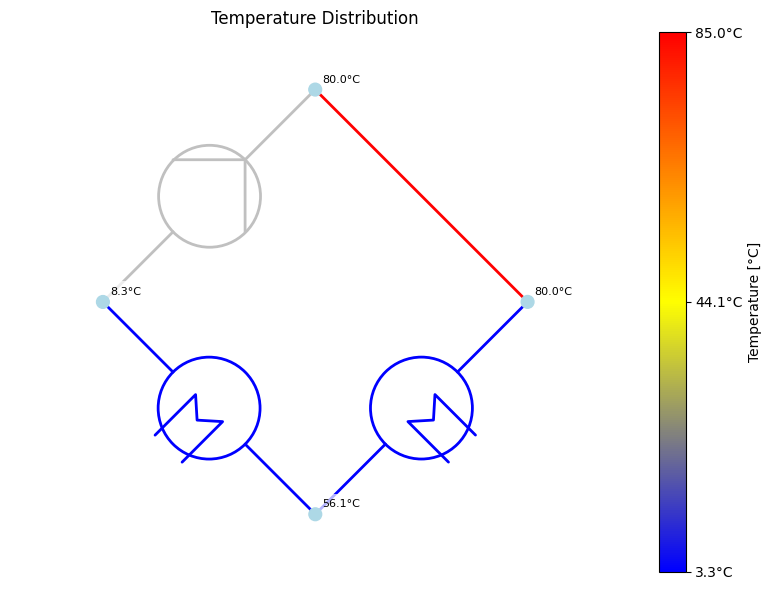

In [6]:
temp_colors = LinearSegmentedColormap.from_list('temp_colors', ['blue', 'yellow', 'red'])
junction_temps = net.res_junction['t_k']
temp_min, temp_max = junction_temps.min() - 5, junction_temps.max() + 5

fig, ax = plt.subplots(figsize=(8, 6))
pp.plotting.simple_plot(net, ax=ax, plot_sinks=True, plot_sources=True, junction_size=1.5,
    pipe_width=2.0, heat_exchanger_size=1.5, pump_size=1.5,
    junction_color='lightblue', pipe_color='red', heat_exchanger_color='blue',
    circ_pump_mass_color='red', show_plot=False)

for idx in net.junction.index:
    temp = net.res_junction.at[idx, 't_k'] - 273.15
    x = net.junction_geodata.at[idx, 'x']
    y = net.junction_geodata.at[idx, 'y']
    ax.annotate(f'{temp:.1f}°C', xy=(x, y), xytext=(5, 5), textcoords='offset points', fontsize=8,
                bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

ax.set_title("Temperature Distribution")
sm = plt.cm.ScalarMappable(cmap=temp_colors)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Temperature [°C]')
temp_points = [temp_min, (temp_min + temp_max)/2, temp_max]
temp_labels = [f"{(t - 273.15):.1f}°C" for t in temp_points]
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(temp_labels)
plt.tight_layout()
plt.show()

## 5. Plot Results: Temperature, Pressure, Flow Velocity

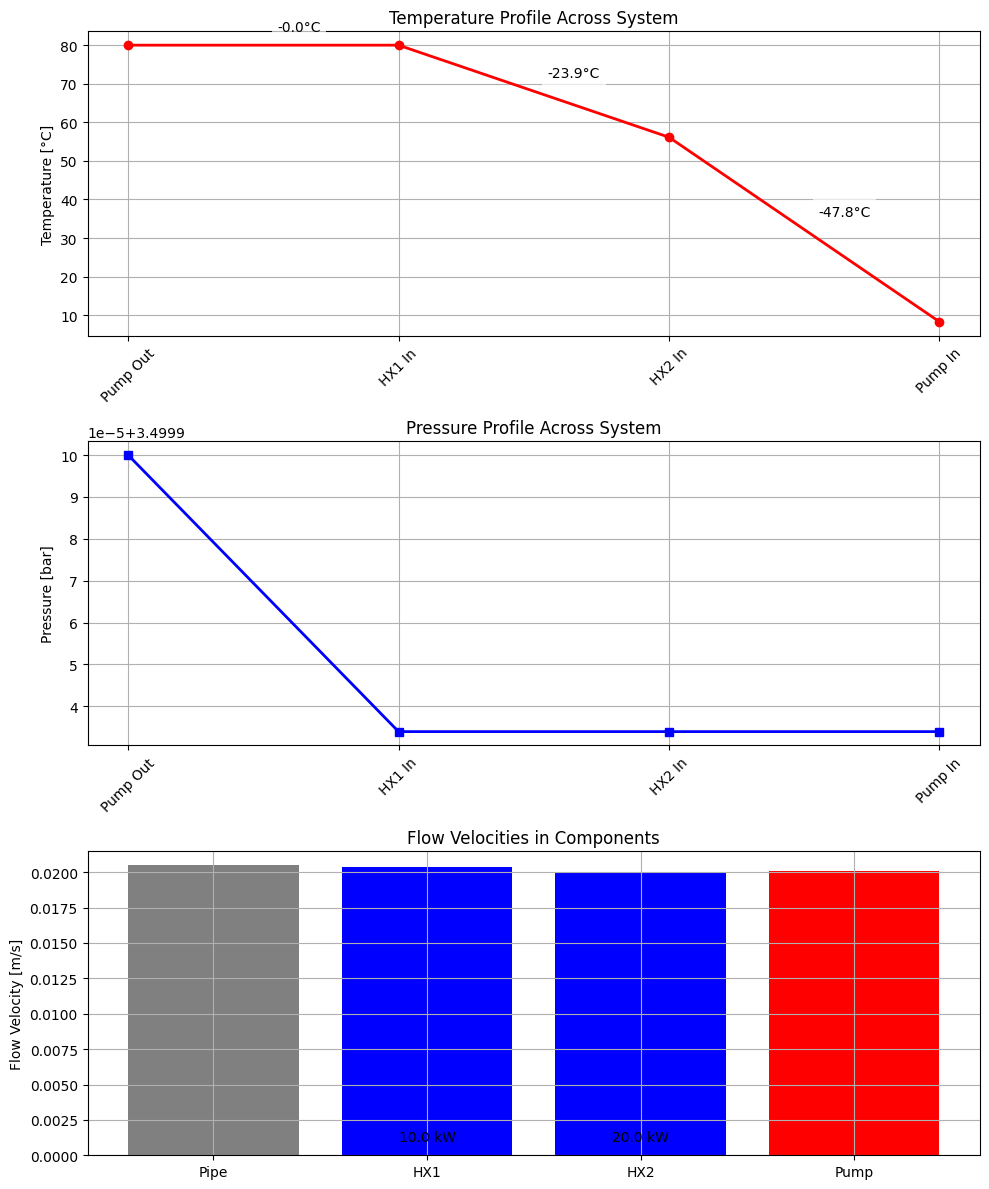

In [7]:
fig_results, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

junction_names = ['Pump Out', 'HX1 In', 'HX2 In', 'Pump In']
temps_c = net.res_junction['t_k'] - 273.15
ax1.plot(range(len(temps_c)), temps_c, 'ro-', linewidth=2)
ax1.set_xticks(range(len(temps_c)))
ax1.set_xticklabels(junction_names, rotation=45)
ax1.set_ylabel('Temperature [°C]')
ax1.set_title('Temperature Profile Across System')
ax1.grid(True)
for i in range(len(temps_c)-1):
    drop = temps_c.iloc[i] - temps_c.iloc[i+1]
    if drop > 0:
        ax1.annotate(f'-{drop:.1f}°C', xy=((i+i+1)/2, (temps_c[i]+temps_c[i+1])/2),
                     xytext=(10, 10), textcoords='offset points',
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.7))

pressures = net.res_junction['p_bar']
ax2.plot(range(len(pressures)), pressures, 'bs-', linewidth=2)
ax2.set_xticks(range(len(pressures)))
ax2.set_xticklabels(junction_names, rotation=45)
ax2.set_ylabel('Pressure [bar]')
ax2.set_title('Pressure Profile Across System')
ax2.grid(True)

components = ['Pipe', 'HX1', 'HX2', 'Pump']
flow_rates = []
flow_rates.append(net.res_pipe['v_mean_m_per_s'].iloc[0] if not net.res_pipe.empty else 0)
for _, hx in net.res_heat_exchanger.iterrows():
    flow_rates.append(hx['vdot_m3_per_s'] / (np.pi * (0.08/2)**2))
flow_rates.append(net.res_circ_pump_mass['vdot_m3_per_s'].iloc[0] / (np.pi * (0.08/2)**2))

ax3.bar(components, flow_rates, color=['gray', 'blue', 'blue', 'red'])
ax3.set_ylabel('Flow Velocity [m/s]')
ax3.set_title('Flow Velocities in Components')
ax3.grid(True)
for i, (_, hx) in enumerate(net.heat_exchanger.iterrows(), start=1):
    ax3.annotate(f'{hx["qext_w"]/1000:.1f} kW', xy=(f'HX{i}', 0),
                 xytext=(0, 10), textcoords='offset points', ha='center')

plt.tight_layout()
plt.show()